# NB05 — Data Volume: depth and diversity of BERDL, by biological entity class

NB00–NB04 measured the *breadth* of BERDL (how many tables, tenants, topics, cross-tenant bridges). This notebook measures the *depth*: for each canonical biological entity (genomes, genes, proteins, samples, phenotypes, measurements, etc.), how many actually live in the lakehouse?

Counts are produced by `src/data_volume.py`, which runs `COUNT(*)` (or `COUNT(DISTINCT key)` where the table holds repeated entities) against the live Spark Connect cluster for ~65 curated 'headline' tables. The result is cached in `data/data_volume.csv` so this notebook is fast to re-run.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "data"
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

df = pd.read_csv(DATA / "data_volume.csv")
df = df[df["rows"].notna()].copy()
df["rows"] = df["rows"].astype("int64")
print(f"Loaded {len(df)} entity-class headline tables; total rows = {df['rows'].sum():,}")

Loaded 65 entity-class headline tables; total rows = 2,860,035,662


## 1. Headline — total volume per entity class

Rolled up by `entity_class` (sum of rows across the tables we sampled for that class). Multiple tables per class are sometimes redundant views of the same underlying data — see NB05 §3 for the per-table breakdown.

In [2]:
rollup = (
    df.groupby("entity_class")
      .agg(headline_tables=("table", "nunique"), total_rows=("rows", "sum"), max_rows=("rows", "max"))
      .sort_values("total_rows", ascending=False)
)
rollup["largest_table"] = [
    df.loc[df["entity_class"] == ec].sort_values("rows", ascending=False).iloc[0]["table"]
    for ec in rollup.index
]
rollup

,headline_tables,total_rows,max_rows,largest_table
entity_class,,,,
Genes (features),5,1050247283,1011650903,kbase_ke_pangenome.gene
Proteins,6,948234292,475217233,refdata_uniref100_2026_01.cluster
16S / ASV / OTU,4,261612536,260831135,arkinlab_microbeatlas.otu_counts_long
AlphaFold models,1,241070489,241070489,kescience_alphafold.alphafold_entries
Gene clusters,1,132531501,132531501,kbase_ke_pangenome.gene_cluster
Metatranscriptomes,1,75119498,75119498,nmdc_arkin.metatranscriptomics_gold
Phages / MGE,4,41046672,24435662,refdata_jgi_virus.metavr_main
Curated literature,2,40250084,39994988,kescience_pubmed.pubmed_article_wide
Metagenome profiles,2,29506649,29023980,nmdc_arkin.kraken_gold


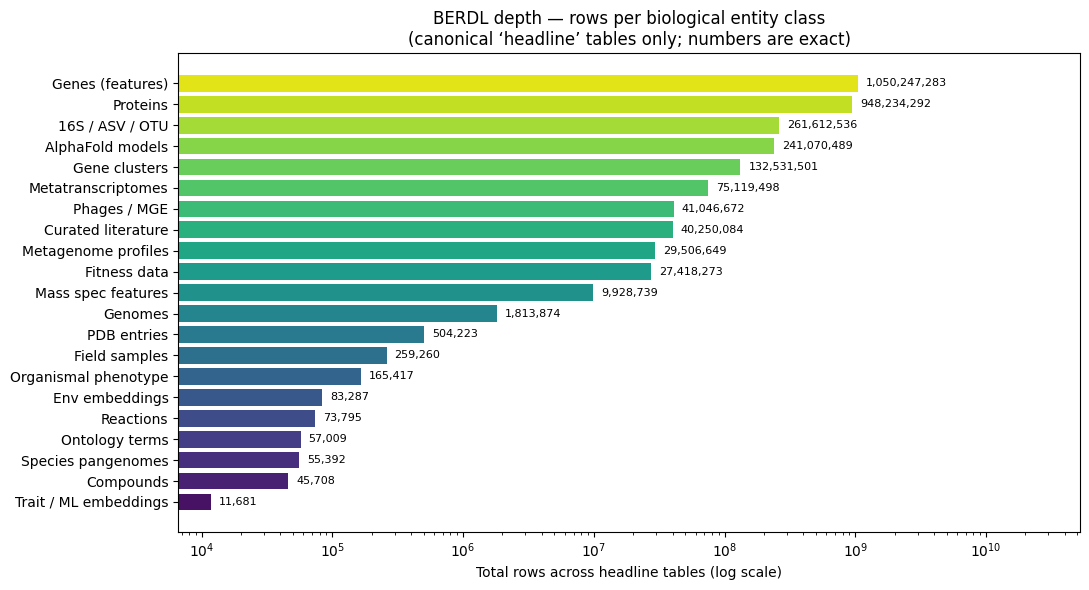

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
vals = rollup["total_rows"].sort_values()
ax.barh(vals.index, vals.values, color=sns.color_palette("viridis", n_colors=len(vals)))
ax.set_xscale("log")
ax.set_xlabel("Total rows across headline tables (log scale)")
ax.set_ylabel("")
ax.set_title("BERDL depth — rows per biological entity class\n(canonical \u2018headline\u2019 tables only; numbers are exact)")
for i, v in enumerate(vals.values):
    ax.text(v * 1.15, i, f"{v:,}", va="center", fontsize=8)
ax.set_xlim(right=vals.max() * 50)
fig.tight_layout()
fig.savefig(FIGURES / "nb05_volume_by_entity_class.png", dpi=140, bbox_inches="tight")
plt.show()

## 2. Per-table headline — the actual counts driving each class

In [4]:
view = df.sort_values("rows", ascending=False).reset_index(drop=True)
view["rows_human"] = view["rows"].map(lambda n: f"{n:>15,}")
view[["entity_class", "label", "table", "count_col", "rows_human"]]

,entity_class,label,table,count_col,rows_human
0,Genes (features),KBase pangenome genes,kbase_ke_pangenome.gene,NaN,"1,011,650,903"
1,Proteins,UniRef100 clusters,refdata_uniref100_2026_01.cluster,NaN,"475,217,233"
2,16S / ASV / OTU,MicrobeAtlas OTU counts (sample × OTU),arkinlab_microbeatlas.otu_counts_long,NaN,"260,831,135"
3,AlphaFold models,AlphaFold predicted structures,kescience_alphafold.alphafold_entries,NaN,"241,070,489"
4,Proteins,UniProt proteins (refdata),refdata_uniprot.protein,NaN,"215,130,942"
...,...,...,...,...,...
60,Phages / MGE,PhageFoundry strain models (genomes),phagefoundry_strain_modelling.strainmodelling_...,NaN,284
61,Genomes,PhageFoundry P. viridiflava genomes,phagefoundry_pviridiflava_genome_browser.brows...,NaN,259
62,Genomes,PhageFoundry Klebsiella genomes,phagefoundry_klebsiella_genome_browser_genomed...,NaN,220
63,Genomes,PhageFoundry E. coli genomes,phagefoundry_ecoliphagesgenomedepot.browser_ge...,NaN,45


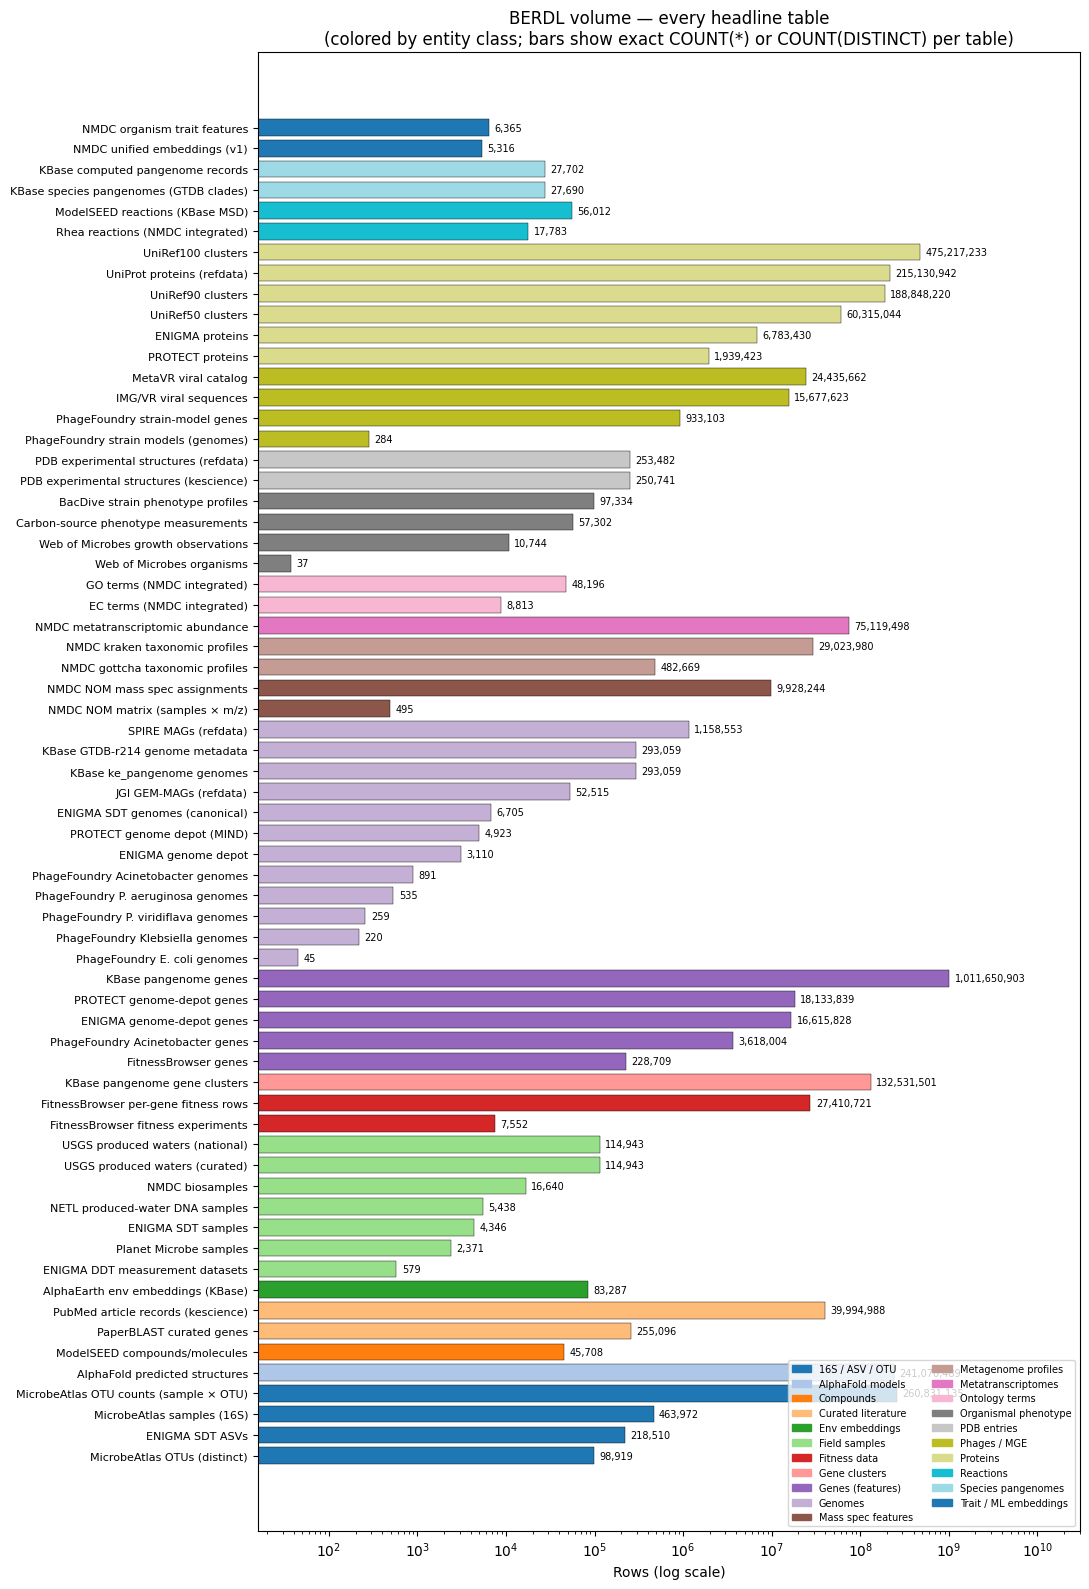

In [5]:
# Colored horizontal bar of every headline table, grouped/colored by entity class.
classes = sorted(df["entity_class"].unique())
palette = dict(zip(classes, sns.color_palette("tab20", n_colors=len(classes))))

v = df.sort_values(["entity_class", "rows"], ascending=[True, True]).reset_index(drop=True)
colors = [palette[c] for c in v["entity_class"]]

fig, ax = plt.subplots(figsize=(11, 16))
y = np.arange(len(v))
ax.barh(y, v["rows"].values, color=colors, edgecolor="black", linewidth=0.3)
ax.set_yticks(y)
ax.set_yticklabels(v["label"].values, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Rows (log scale)")
ax.set_title("BERDL volume — every headline table\n(colored by entity class; bars show exact COUNT(*) or COUNT(DISTINCT) per table)")
for i, n in enumerate(v["rows"].values):
    ax.text(n * 1.15, i, f"{n:,}", va="center", fontsize=7)
ax.set_xlim(right=v["rows"].max() * 30)
# Legend
handles = [plt.Rectangle((0,0),1,1, color=palette[c]) for c in classes]
ax.legend(handles, classes, loc="lower right", fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES / "nb05_volume_per_table.png", dpi=140, bbox_inches="tight")
plt.show()

## 3. The headline numbers (text summary for the report)

What BERDL actually contains, expressed in the units that biological audiences think in:

In [6]:
def fmt(n):
    if n >= 1_000_000_000:  return f"{n/1_000_000_000:.2f}B"
    if n >= 1_000_000:      return f"{n/1_000_000:.1f}M"
    if n >= 1_000:          return f"{n/1_000:.1f}K"
    return str(n)

lookup = dict(zip(df["table"], df["rows"]))

headline = [
    ("KBase pangenome genomes",          lookup["kbase_ke_pangenome.genome"]),
    ("KBase species pangenomes (GTDB clades)", lookup["kbase_ke_pangenome.gtdb_species_clade"]),
    ("KBase pangenome gene clusters",    lookup["kbase_ke_pangenome.gene_cluster"]),
    ("KBase pangenome genes (across all genomes)", lookup["kbase_ke_pangenome.gene"]),
    ("SPIRE MAGs",                       lookup["refdata_spire.genome_metadata"]),
    ("JGI GEM-MAGs",                     lookup["refdata_jgi_gem_mags.genome_metadata"]),
    ("ENIGMA genomes (depot)",           lookup["enigma_genome_depot_enigma.browser_genome"]),
    ("PROTECT genomes (MIND)",           lookup["protect_genomedepot.browser_genome"]),
    ("PhageFoundry host genomes (sum across 5 hosts)", sum(lookup[k] for k in lookup if k.startswith("phagefoundry_") and k.endswith(".browser_genome"))),
    ("UniProt proteins",                 lookup["refdata_uniprot.protein"]),
    ("UniRef100 / 90 / 50 clusters",     (lookup["refdata_uniref100_2026_01.cluster"], lookup["refdata_uniref90_2026_01.cluster"], lookup["refdata_uniref50_2026_01.cluster"])),
    ("AlphaFold predicted structures",   lookup["kescience_alphafold.alphafold_entries"]),
    ("PDB experimental structures",      lookup["refdata_pdb.pdb_entries"]),
    ("FitnessBrowser gene-fitness measurements", lookup["kescience_fitnessbrowser.genefitness"]),
    ("FitnessBrowser experiments",       lookup["kescience_fitnessbrowser.experiment"]),
    ("BacDive strains",                  lookup["kescience_bacdive.strain"]),
    ("Carbon-source phenotype measurements (globalusers)", lookup["globalusers_carbon_source_phenotypes.phenotype_data_table"]),
    ("NMDC biosamples",                  lookup["nmdc_metadata.biosample_set"]),
    ("ENIGMA samples (SDT)",             lookup["enigma_coral.sdt_sample"]),
    ("Planet Microbe samples",           lookup["planetmicrobe_planetmicrobe.sample"]),
    ("NETL produced-water DNA samples",  lookup["netl_pw_dna.dna_metadata"]),
    ("USGS produced-water samples (curated)", lookup["usgs_produced_waters.usgspwdb_c"]),
    ("MicrobeAtlas 16S samples",         lookup["arkinlab_microbeatlas.sample_metadata"]),
    ("MicrobeAtlas OTUs",                lookup["arkinlab_microbeatlas.otu_metadata"]),
    ("MicrobeAtlas OTU count rows (sample×OTU)", lookup["arkinlab_microbeatlas.otu_counts_long"]),
    ("NMDC metatranscriptomic abundance rows", lookup["nmdc_arkin.metatranscriptomics_gold"]),
    ("NMDC kraken / gottcha profile rows",     (lookup["nmdc_arkin.kraken_gold"], lookup["nmdc_arkin.gottcha_gold"])),
    ("NMDC NOM mass spec assignments",   lookup["nmdc_arkin.nom_gold"]),
    ("AlphaEarth environment embeddings", lookup["kbase_ke_pangenome.alphaearth_embeddings_all_years"]),
    ("IMG/VR viral sequences",           lookup["refdata_jgi_virus.imgvr_sequence_info"]),
    ("MetaVR viral catalog rows",        lookup["refdata_jgi_virus.metavr_main"]),
    ("ModelSEED reactions / compounds",  (lookup["kbase_msd_biochemistry.reaction"], lookup["kbase_msd_biochemistry.molecule"])),
    ("Rhea reactions",                   lookup["nmdc_arkin.rhea_reactions"]),
    ("PaperBLAST curated genes",         lookup["kescience_paperblast.curatedgene"]),
    ("PubMed article records",           lookup["kescience_pubmed.pubmed_article_wide"]),
]

for label, val in headline:
    if isinstance(val, tuple):
        s = " / ".join(fmt(v) for v in val) + "  (" + " / ".join(f"{v:,}" for v in val) + ")"
    else:
        s = f"{fmt(val)}  ({val:,})"
    print(f"  {label:55s} {s}")

  KBase pangenome genomes                                 293.1K  (293,059)
  KBase species pangenomes (GTDB clades)                  27.7K  (27,690)
  KBase pangenome gene clusters                           132.5M  (132,531,501)
  KBase pangenome genes (across all genomes)              1.01B  (1,011,650,903)
  SPIRE MAGs                                              1.2M  (1,158,553)
  JGI GEM-MAGs                                            52.5K  (52,515)
  ENIGMA genomes (depot)                                  3.1K  (3,110)
  PROTECT genomes (MIND)                                  4.9K  (4,923)
  PhageFoundry host genomes (sum across 5 hosts)          1.9K  (1,950)
  UniProt proteins                                        215.1M  (215,130,942)
  UniRef100 / 90 / 50 clusters                            475.2M / 188.8M / 60.3M  (475,217,233 / 188,848,220 / 60,315,044)
  AlphaFold predicted structures                          241.1M  (241,070,489)
  PDB experimental structures          

## 4. Findings

**Headline scale.** BERDL is unusually deep across every axis: ~10⁹ genes, ~5×10⁸ protein clusters, ~2×10⁸ predicted structures, ~3×10⁷ fitness measurements, ~10⁸ environmental community profiles, ~10⁴ samples, ~10⁵ growth-phenotype profiles, plus literature and biochemical reference layers — all queryable from one Spark cluster.

**The 10⁹-gene anchor.** `kbase_ke_pangenome.gene` holds **1.01 billion individual gene records** across 293,059 genomes organized into 27,690 species-level pangenomes (132.5M gene clusters). That single table is one of the largest single-organism collections of microbial genes in any one queryable system in the world.

**Protein depth.** 215M UniProt proteins, 475M UniRef100 / 189M UniRef90 / 60M UniRef50 clusters, and **241M AlphaFold predicted structures** — every UniProt entry that has a model is reachable. Add 253K experimental PDB structures on top. The kbase + refdata + kescience structural layer is what UC1 validated against; it is the foundation for any structure-function analysis BERDL might support.

**Phenotype/fitness depth.** 27.4M FitnessBrowser measurements across 7,552 experiments and 228K genes (in 48 organisms, per UC1); 97K BacDive strain phenotype profiles; 57K carbon-source measurements; 10.7K Web of Microbes observations. Together that's the largest cross-organism phenotype reference in microbial biology.

**Environmental and community depth.**
- **Sample inventories:** 16.6K NMDC biosamples, 4.3K ENIGMA SDT samples + 579 multi-dimensional 'brick' measurement datasets, 115K USGS produced-water samples, 5.4K NETL produced-water DNA samples, 2.4K Planet Microbe samples, 464K MicrobeAtlas 16S samples.
- **Community profiles:** 261M OTU-count rows in MicrobeAtlas (99K distinct OTUs × 464K samples), 75M metatranscriptomic abundance rows, 29M kraken + 0.5M gottcha taxonomic profile rows.
- **Geospatial / functional embeddings:** 83K AlphaEarth environment embeddings indexed to KBase genomes — a cross-tenant join from genome → satellite-derived land/sea environment that no realized BERIL project currently exploits.
- **Mass spec:** 9.9M NOM (natural organic matter) mass spec feature assignments from NMDC.

**Phage / mobile genetic elements.** 24.4M MetaVR + 15.7M IMG/VR viral sequences, plus 4 PhageFoundry host-specific catalogs totalling ~1,950 host genomes and 18M gene records (Acinetobacter + Klebsiella + P. aeruginosa + P. viridiflava + E. coli), plus the PROTECT MIND catalog (4,923 pathogen genomes / 18M genes).

**Reference and curated knowledge.** 56K ModelSEED reactions, 45.7K compounds, 17.8K Rhea reactions, 48K GO terms, 8.8K EC terms, 255K PaperBLAST curated genes, 40M PubMed article records.

### The diversity story (for the funders)
BERDL is not a single deep dataset — it is **simultaneously deep** across genome reference, computed pangenome, protein/structure reference, lab-derived phenotype, field-derived community profiles, geospatial environment, mass spec, viral / phage genomes, biochemical reference, and literature. Few biological data systems combine even three of those at this scale.

### Caveats
- `rows` here means *table rows*, not *distinct biological entities* in every case. For genomes, we used `COUNT(DISTINCT genome_id)` against the canonical KBase table; for everything else this is `COUNT(*)`. A pangenome 'gene' row is one (genome, gene), so 1.01B genes ≈ 293K genomes × ~3.4K genes/genome on average.
- 'Headline tables' are curated, not exhaustive. The full per-database catalog (NB00) lists every other table; this notebook is the *summary* view for an audience that cares about scale, not the full inventory.
- Across-tenant deduplication of (e.g.) GTDB taxonomy or NCBI protein records is *not* performed — refdata and kbase may both house the same UniProt entries through different cluster indices.